In [1]:
import torch
import CT.Models.misc as misc
import CT.Inference.Kolmogorov.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
"/scratch/ql2221/CT_models/wandb_data/wandb/run-20260112_141849-pg7cty6s/files"
ACDM_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20251222_190732-fsmbur5c/files/checkpoint_last.p"
# ACDM_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20251219_055223-ftricfml/files/checkpoint_last.p"
ACDM = misc.load_ACDM(ACDM_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [2]:
ACDM.config['diffusion_steps']

200

In [3]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p")
data = data_dict["data"]/4.44
data_dict["data_config"]

/state/partition1/job-1299202/ipykernel_3730484/2483025451.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_fl

{'n_sims': 5,
 'n_traj': 1,
 'chunk_size': 10000,
 'nsteps': 100000,
 'dt': 0.001,
 'Dt': 0.002,
 'spinup': 10000,
 'decorr_steps': 0,
 'reynolds': 10000,
 'gridsize': 512,
 'downsample': 8,
 'save_path': '/scratch/ql2221/thermalizer_data/kolmogorov/reynold10k/Long_numerical_rollout.p',
 'viscosity': 0.0001,
 'Dt/dt': 2.0}

In [4]:
x = data[0:1].to(device)

#getting x_t and noise it
x_t = x[:,-1:]
noise = torch.randn_like(x[:,-1:]).to(device)
s = torch.tensor([200]).to(device)
x_t_noised = ACDM._forward_diffusion(x_t, s-1, noise).to(device)

In [5]:
x_t_short_lag = x[:,-2:-1].to(device)

x_conditional = torch.cat((x_t_short_lag, x_t_noised), dim=1).to(device)
x_denoised = ACDM.denoising(x_conditional, s)

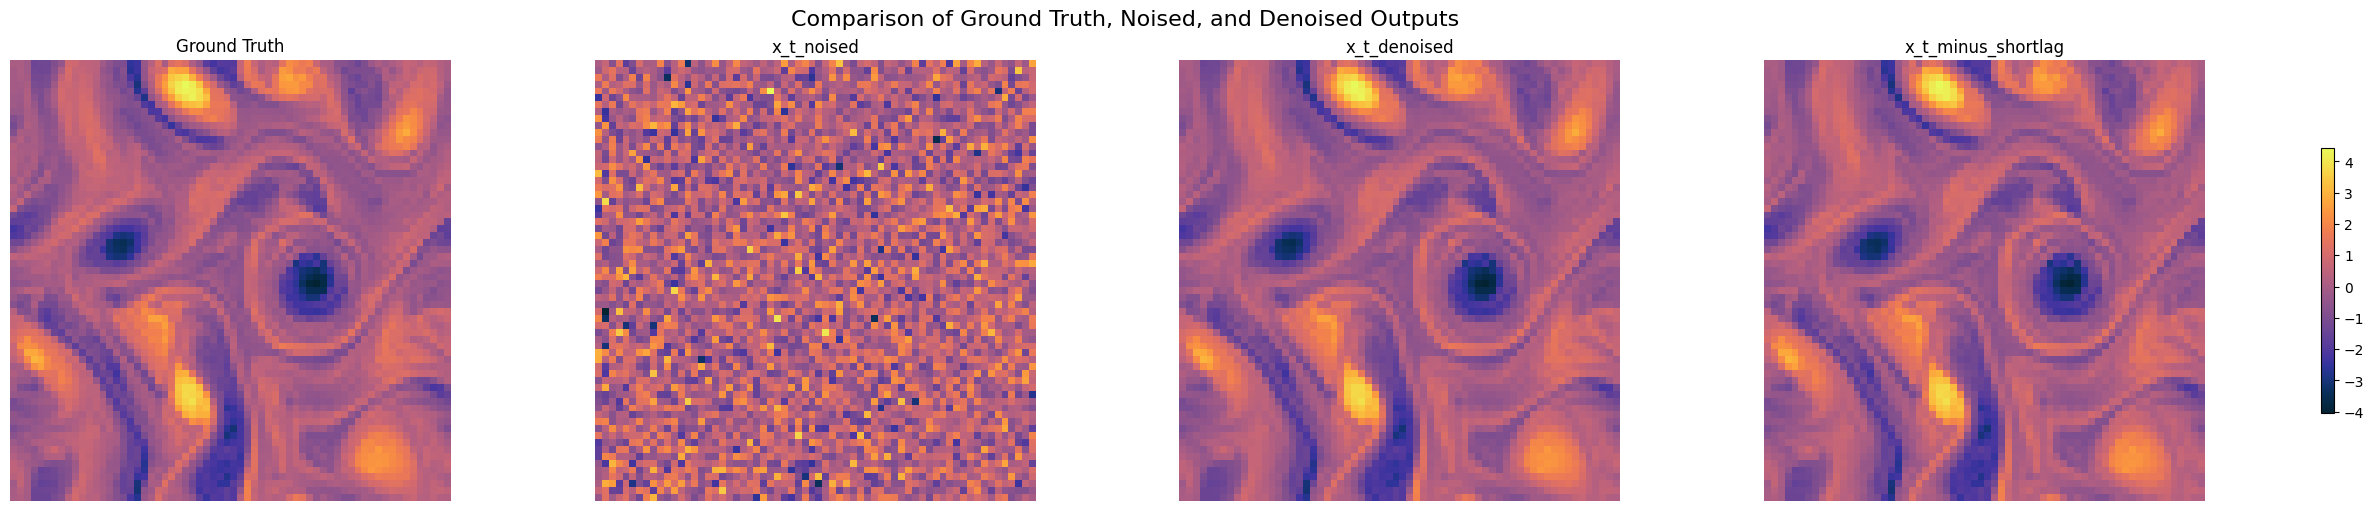

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t,                
    x_t_noised,
    x_denoised,
    x_t_short_lag,
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
import torch

@torch.no_grad()
def k_step_denoise_then_tweedie(
    acdm, 
    x, 
    k: int, 
    start_t: int = None,
    return_all: bool = False,
):
    """
    Standalone utility (callable outside the class).

    Args:
        acdm: instance of ACDM_NS (must have .model and diffusion buffers)
        x:    tensor [B, 2, H, W] where x[:,-1:] is the noisy sample to denoise and
              x[:,-2:-1] is the short-lag conditional
        k:    number of reverse steps to run (k-step denoising)
        start_t: starting diffusion timestep (int). If None, uses (acdm.diffusion_steps - 1).
                 The function will denoise from start_t down to (start_t - k + 1).
        return_all: if True, returns a dict of intermediates.

    Returns:
        If return_all=False:
            x_t:        denoised sample after k reverse steps (still at timestep t_final)
            x0_tweedie: Tweedie estimate of x0 from x_t at timestep t_final
            t_final:    the timestep index where Tweedie was applied
        If return_all=True:
            dict with keys: x_t, x0_tweedie, t_final, eps_pred
    """
    assert x.dim() == 4 and x.size(1) >= 2, "Expected x shape [B, 2, H, W] (or more channels with last two used)."
    B = x.size(0)
    device = x.device

    # Start timestep
    if start_t is None:
        start_t = int(acdm.diffusion_steps - 1)
    start_t = int(start_t)

    # Clamp k to valid range
    k = int(k)
    if k <= 0:
        raise ValueError("k must be >= 1.")
    if start_t < 0 or start_t >= acdm.diffusion_steps:
        raise ValueError(f"start_t must be in [0, {acdm.diffusion_steps-1}]")

    # We'll step down k times: start_t, start_t-1, ..., t_final
    t_final = max(start_t - (k - 1), 0)

    # Initialize current sample x_t as the last channel
    x_t = x[:, -1:].clone()
    x_t_short_lag = x[:, -2:-1].clone()

    # k-step reverse diffusion
    for i in range(start_t, t_final - 1, -1):
        s = torch.full((B,), i, device=device, dtype=torch.long)

        # noise used for the reverse step (same as your denoising method)
        z = torch.randn_like(x_t, device=device)

        # prepare conditional short-lag input (same logic as in your class)
        if acdm.config.get("noise_short_lag", False):
            if acdm.config.get("different_noise", False):
                z1 = torch.randn_like(x_t, device=device)
                x_short = acdm._forward_diffusion(x_t_short_lag, s, z1)
            else:
                x_short = acdm._forward_diffusion(x_t_short_lag, s, z)
        else:
            x_short = x_t_short_lag

        x_in = torch.cat((x_short, x_t), dim=1)
        x_t = acdm._reverse_diffusion(x_in, s, z)

    # ---- Tweedie formula at timestep t_final ----
    s = torch.full((B,), t_final, device=device, dtype=torch.long)

    # re-build the conditional at that timestep for eps prediction
    if acdm.config.get("noise_short_lag", False):
        # For Tweedie, you don't *need* to sample noise for the conditional;
        # but to match your conditioning scheme, we can noising short-lag with fresh noise.
        # (If you'd rather keep it deterministic, set z_cond = 0.)
        z_cond = torch.randn_like(x_t, device=device)
        if acdm.config.get("different_noise", False):
            z_cond1 = torch.randn_like(x_t, device=device)
            x_short = acdm._forward_diffusion(x_t_short_lag, s, z_cond1)
        else:
            x_short = acdm._forward_diffusion(x_t_short_lag, s, z_cond)
    else:
        x_short = x_t_short_lag

    x_in = torch.cat((x_short, x_t), dim=1)
    eps_pred = acdm.model(x_in, None, None, s)

    # Tweedie / posterior mean estimate of x0 from xt and eps_pred:
    # x0_hat = (xt - sqrt(1 - alpha_bar_t) * eps_pred) / sqrt(alpha_bar_t)
    alpha_bar = acdm.alphas_cumprod.gather(-1, s).reshape(B, 1, 1, 1)
    sqrt_alpha_bar = torch.sqrt(alpha_bar)
    sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)
    x0_tweedie = (x_t - sqrt_one_minus_alpha_bar * eps_pred) / (sqrt_alpha_bar + 1e-12)

    if return_all:
        return {
            "x_t": x_t,
            "x0_tweedie": x0_tweedie,
            "t_final": t_final,
            "eps_pred": eps_pred,
        }
    return x_t, x0_tweedie, t_final


In [8]:
x = data[0:1].to(device)

#getting x_t and noise it
x_t = x[:,-1:]
noise = torch.randn_like(x[:,-1:]).to(device)
s = torch.tensor([200]).to(device)
x_t_noised = ACDM._forward_diffusion(x_t, s-1, noise).to(device)
x_t_short_lag = x[:,-2:-1].to(device)

x_conditional = torch.cat((x_t_short_lag, x_t_noised), dim=1).to(device)
x_t_k, x0_hat, t_final = k_step_denoise_then_tweedie(
    acdm=ACDM,          # your ACDM_NS instance
    x=x_conditional,
    k=10,
    start_t=199
)

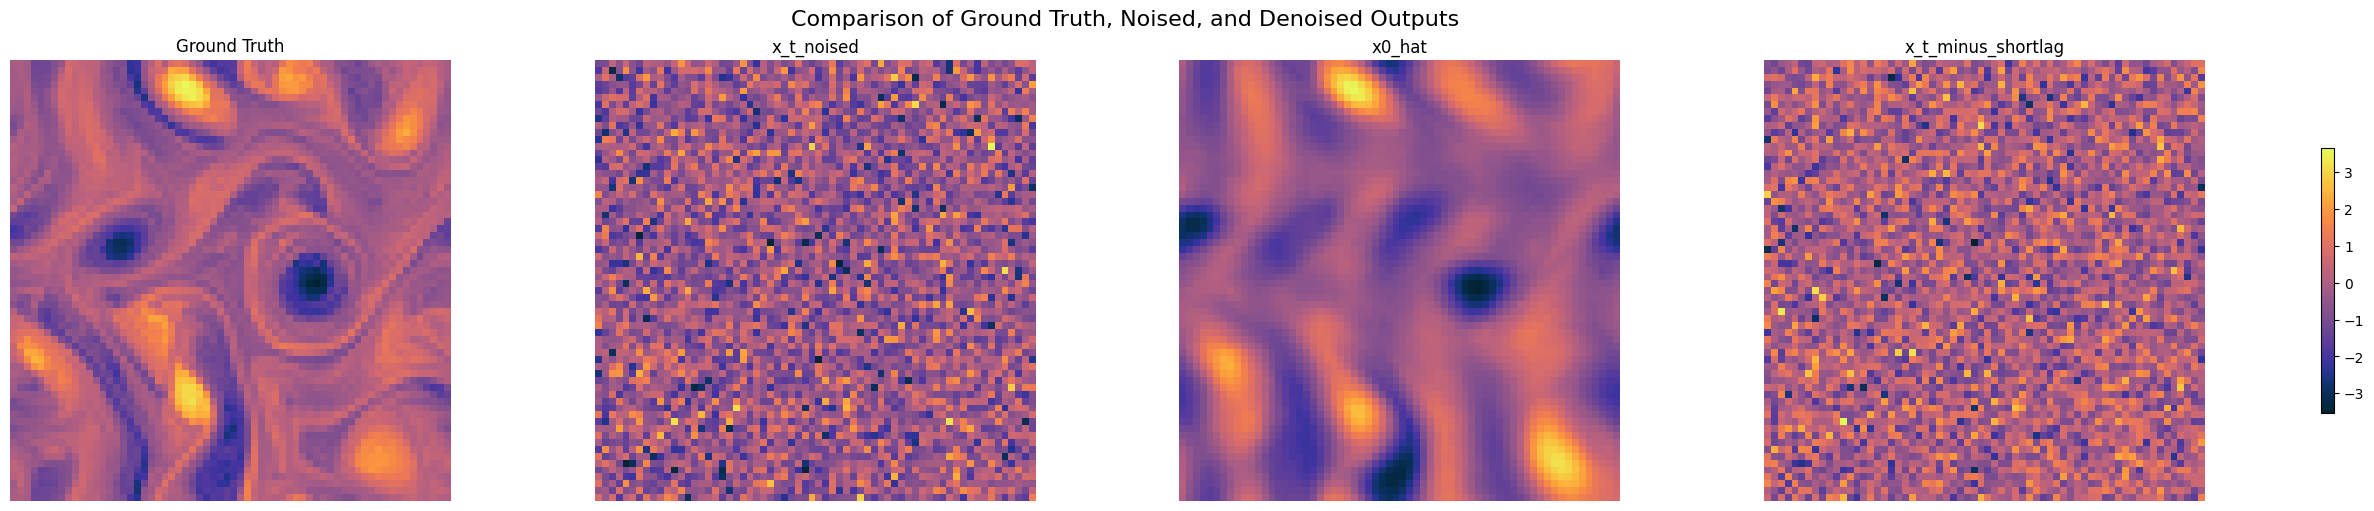

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t,                
    x_t_noised,
    x0_hat,
    x_t_k,
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x0_hat',
    'x_t_minus_shortlag',
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
def ACDM_rollout(ics, ACDM, n_steps, denoising_steps = 10, silence = False):
    state_vector=torch.zeros((len(ics),n_steps,64,64),device=ics.device)
    state_vector[:,0:1]=ics
    state_vector=state_vector.to(ics.device)

    with torch.no_grad(): 
        for aa in tqdm(range(1,n_steps),disable=silence):
            x_t_short_lag = state_vector[:,aa-1].unsqueeze(1)
            x_t = ACDM._forward_diffusion(x_t_short_lag, denoising_steps-1).to(device)
            new_conditional = torch.cat((x_t_short_lag,x_t), dim = 1)
            state_vector[:,aa]=ACDM.denoising(new_conditional, denoising_steps).squeeze()
    return state_vector
ACDM.eval()

ACDM_NS(
  (model): ModernUnet(
    (activation): GELU(approximate='none')
    (image_proj): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (third_mlp1): Linear(in_features=512, out_features=512, bias=True)
    (third_mlp2): Linear(in_features=512, out_features=512, bias=True)
    (down): ModuleList(
      (0): Down_block(
        (res): Residual_block(
          (activation): GELU(approximate='none')
          (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
          (shortcut): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), padding_mode=circular)
          (norm1): Identity()
          (norm2): Identity()
          (third_dense1): Linear(in_features=512, out_features=128, bias=True)
          (third_dense2): Linear(in_features=512, out_features=128, bias=True)
        )
       

In [8]:
rollout = ACDM_rollout(data[:,0:1].to(device), ACDM, n_steps = 3000, denoising_steps = 200, silence = False)

100%|██████████| 2999/2999 [1:01:52<00:00,  1.24s/it]


In [12]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")  # safe on headless/HPC
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib as mpl

def make_movie(state_vector, save_path="ACDM_1layer.mp4", fps=30,
                      vmin=None, vmax=None, stride=10, cmap=None):
    """
    Movie for a *single-layer* field stored as a 4D/5D tensor:

      - supported shapes:
          (B, T, H, W)            or
          (B, T, 1, H, W)

    Behavior:
      - uses imageio-ffmpeg if available
      - uses codec='mpeg4' to avoid libx264 dependency
      - symmetric vmin/vmax if not provided
      - plots B rows x 1 column (one panel per batch)
      - optional GIF fallback if MP4 fails
    """

    # Prefer self-contained ffmpeg (HPC/Singularity-safe)
    try:
        import imageio_ffmpeg as iio
        mpl.rcParams["animation.ffmpeg_path"] = iio.get_ffmpeg_exe()
    except Exception:
        pass

    # Default colormap
    if cmap is None:
        cmap = "viridis"

    # Normalize input shape
    arr = state_vector
    if hasattr(arr, "detach"):
        arr = arr.detach().cpu().numpy()
    else:
        arr = np.asarray(arr)

    if arr.ndim == 4:
        # (B, T, H, W)
        B, T, H, W = arr.shape
        data = arr
    elif arr.ndim == 5:
        # (B, T, 1, H, W)
        B, T, L, H, W = arr.shape
        assert L == 1, f"Expected L==1 for single-layer movie, got L={L}"
        data = arr[:, :, 0]  # -> (B, T, H, W)
    else:
        raise ValueError(f"Expected 4D (B,T,H,W) or 5D (B,T,1,H,W); got shape {arr.shape}")

    frame_indices = list(range(0, T, stride))

    # vmin/vmax: if not provided, use symmetric global limits across all batches/times
    if vmin is None or vmax is None:
        m = float(np.nanmax(np.abs(data)))
        vmin = -m
        vmax =  m

    # Layout: B rows x 1 col
    fig, axes = plt.subplots(B, 1, figsize=(6, 4.5 * B), squeeze=False)
    ims = [None] * B

    for b in range(B):
        ax = axes[b, 0]
        im = ax.imshow(
            data[b, 0],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin="upper",
        )
        ax.set_title(f"Batch {b} — Timestep 0")
        ax.set_xticks([])
        ax.set_yticks([])
        ims[b] = im

    # One shared colorbar for all batches
    fig.colorbar(ims[0], ax=axes.ravel().tolist(), shrink=0.9)

    def update(k):
        t = frame_indices[k]
        artists = []
        for b in range(B):
            ims[b].set_data(data[b, t])
            axes[b, 0].set_title(f"Batch {b} — Timestep {t}")
            artists.append(ims[b])
        return artists

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frame_indices),
        blit=False,
        repeat=False
    )

    # Save MP4 with MPEG-4 Part 2 (no x264)
    try:
        Writer = animation.writers["ffmpeg"]
        writer = Writer(
            fps=fps,
            codec="mpeg4",
            bitrate=20000,
            extra_args=["-pix_fmt", "yuv420p"]
        )
        ani.save(save_path, writer=writer)
        print(f"movie saved: {save_path}")
    except Exception as e:
        base, _ = os.path.splitext(save_path)
        gif_path = base + ".gif"
        print(f"MP4 save failed ({type(e).__name__}: {e}). Falling back to GIF: {gif_path}")

        writer = animation.PillowWriter(fps=fps)
        ani.save(gif_path, writer=writer)
        print(f"movie saved: {gif_path}")
    finally:
        plt.close(fig)


In [13]:
make_movie(rollout, "ACDM_200.mp4")

movie saved: ACDM_200.mp4


In [15]:
make_movie(x[0:1,0:10000], save_path="GT.mp4")

movie saved: GT.mp4


In [9]:
torch.save(rollout,  "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ACDM200_ICML.p")